# Trend Analysis: Languages & Technologies

This notebook focuses on analyzing the **temporal trends** of specific programming languages, frameworks, and technologies found in the StackOverflow dataset.

**Goals:**
1. Extract individual technology tags from the dataset.
2. Calculate the relative popularity (market share) of each tech over time.
3. Identify **Rising Stars** (fastest growing) and **Declining** technologies.
4. Forecast future trends using simple regression.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

print("✅ Libraries imported.")

✅ Libraries imported.


## 1. Load Data
We use the `predictions.csv` file generated from the previous step, which contains the cleaned tags (`features`) and dates for millions of StackOverflow posts.

In [2]:
import os

file_path = 'predictions.csv'
if not os.path.exists(file_path):
    print("⚠️ predictions.csv not found. Please run train-01.ipynb first to generate it.")
else:
    print("📥 Loading data...")
    # Read date and features. We don't need the subfield label for this analysis.
    df = pd.read_csv(file_path, usecols=['date_posted', 'features'])
    df['date_posted'] = pd.to_datetime(df['date_posted'])
    
    # Remove rows with missing features
    df = df.dropna(subset=['features'])
    
    print(f"✅ Loaded {len(df)} posts.")
    print(df.head())

📥 Loading data...
✅ Loaded 5517421 posts.
  date_posted     features
0  2018-10-25          c++
1  2014-10-06     css html
2  2018-10-31          vba
3  2015-07-22            r
4  2016-09-24  laravel php


## 2. Data Processing
We need to "explode" the `features` column so that each tag becomes a separate row. This allows us to count occurrences of every single technology.

In [3]:
# 1. Convert space-separated string to list
df['tags'] = df['features'].str.split()

# 2. Explode the list to separate rows
df_exploded = df.explode('tags')

# 3. Create a Month-Year column for aggregation
df_exploded['month'] = df_exploded['date_posted'].dt.to_period('M')

print(f"✅ Total Tag Occurrences: {len(df_exploded)}")
print(df_exploded[['date_posted', 'tags']].head())

✅ Total Tag Occurrences: 7926550
  date_posted  tags
0  2018-10-25   c++
1  2014-10-06   css
1  2014-10-06  html
2  2018-10-31   vba
3  2015-07-22     r


## 3. Calculate Relative Popularity (%)
Raw counts can be misleading if the total activity on StackOverflow changes. We calculate the **percentage share** of each tag per month.

In [4]:
# Count occurences of each tag per month
monthly_counts = df_exploded.groupby(['month', 'tags']).size().reset_index(name='count')

# Count TOTAL posts per month (to calculate percentage)
# Note: We use the original df for total posts, or sum of tags? 
# Standard practice: % of questions that have this tag. 
# Since a question has multiple tags, sum of % > 100%. This is fine.
total_posts_per_month = df.groupby(df['date_posted'].dt.to_period('M')).size().reset_index(name='total_posts')
total_posts_per_month.columns = ['month', 'total_posts']

# Merge
trend_df = monthly_counts.merge(total_posts_per_month, on='month')
trend_df['percentage'] = (trend_df['count'] / trend_df['total_posts']) * 100
trend_df['month_dt'] = trend_df['month'].dt.to_timestamp()

print("✅ Monthly trends calculated.")
print(trend_df.head())

✅ Monthly trends calculated.
     month       tags  count  total_posts  percentage   month_dt
0  2014-01       .net   1486        66189    2.245086 2014-01-01
1  2014-01  angularjs   1740        66189    2.628836 2014-01-01
2  2014-01    ansible     24        66189    0.036260 2014-01-01
3  2014-01     apache    608        66189    0.918582 2014-01-01
4  2014-01    asp.net   1742        66189    2.631857 2014-01-01


## 4. Visualize Top Technologies
Let's look at the "Titans" of the industry.

🏆 Top 10 Technologies: ['python', 'javascript', 'java', 'c#', 'php', 'html', 'c++', 'css', 'jquery', 'r']


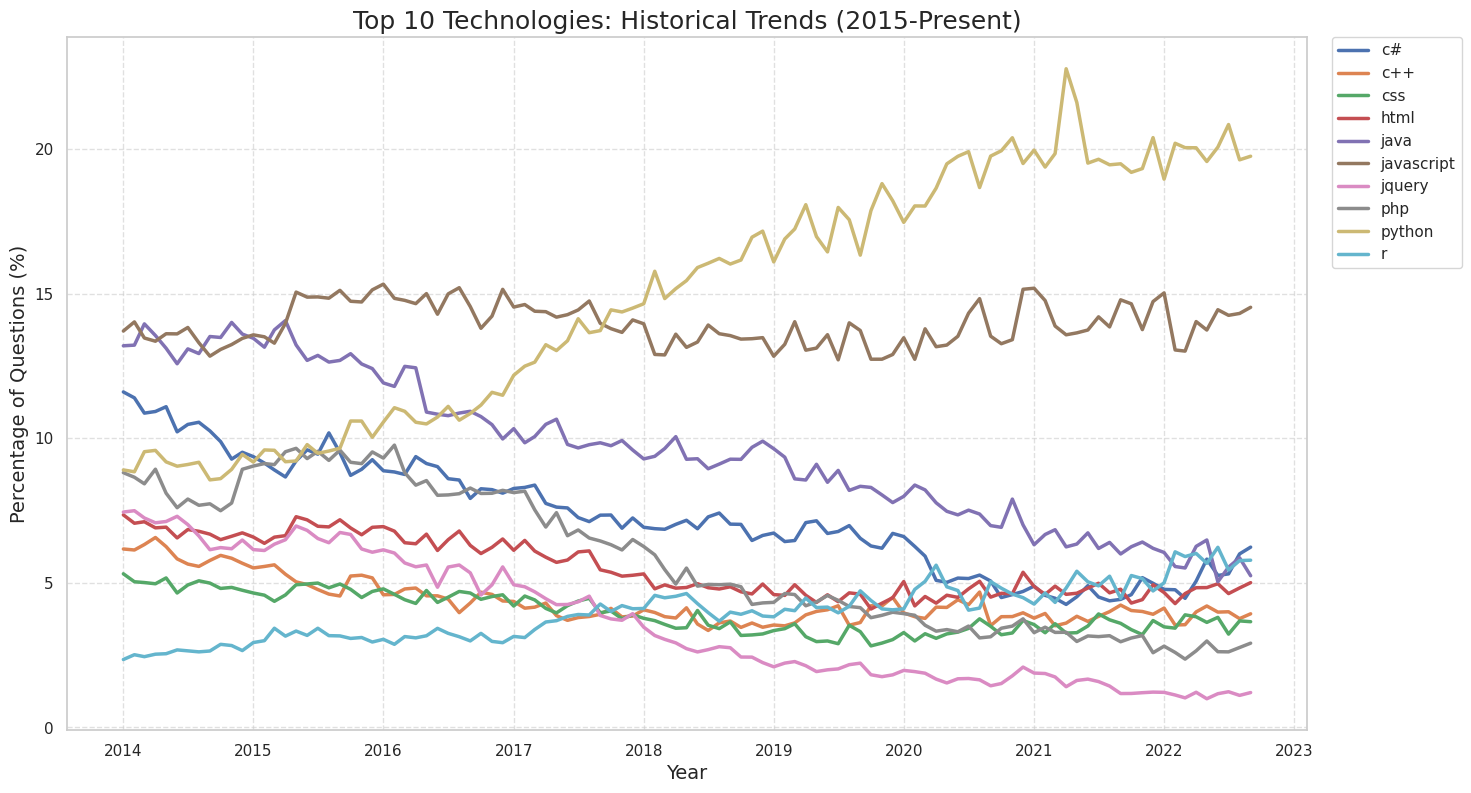

In [5]:
# Identify Top 10 tags by total volume
top_tags = df_exploded['tags'].value_counts().nlargest(10).index.tolist()

print(f"🏆 Top 10 Technologies: {top_tags}")

# Filter data for these tags
top_trend_df = trend_df[trend_df['tags'].isin(top_tags)]

plt.figure(figsize=(16, 9))
sns.lineplot(data=top_trend_df, x='month_dt', y='percentage', hue='tags', linewidth=2.5)

plt.title('Top 10 Technologies: Historical Trends (2015-Present)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Percentage of Questions (%)', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Detect Rising & Falling Stars (Growth Analysis)
We calculate the **Slope** of the trend line over the last 2 years to identify which technologies are gaining or losing traction fastest.

In [6]:
# Filter for the last 24 months
last_date = trend_df['month_dt'].max()
start_date = last_date - pd.DateOffset(months=24)

recent_df = trend_df[trend_df['month_dt'] >= start_date]

# Get list of tags that are at least somewhat relevant (e.g., > 0.1% popularity on average)
avg_pop = recent_df.groupby('tags')['percentage'].mean()
relevant_tags = avg_pop[avg_pop > 0.1].index.tolist()

slopes = []

for tag in relevant_tags:
    tag_data = recent_df[recent_df['tags'] == tag]
    if len(tag_data) < 12: continue  # Skip if not enough data
    
    # Linear Regression
    X = np.arange(len(tag_data)).reshape(-1, 1)
    y = tag_data['percentage'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Slope represents monthly growth rate (% change per month)
    slopes.append({'tag': tag, 'slope': model.coef_[0], 'current_share': y[-1]})

slope_df = pd.DataFrame(slopes)

# Top Growers
top_growers = slope_df.sort_values('slope', ascending=False).head(10)

# Top Decliners
top_decliners = slope_df.sort_values('slope', ascending=True).head(10)

print("🚀 FASTEST GROWING (Last 2 Years):")
display(top_growers)

print("📉 FASTEST DECLINING (Last 2 Years):")
display(top_decliners)

🚀 FASTEST GROWING (Last 2 Years):


,tag,slope,current_share
77,reactjs,0.070909,7.493439
76,r,0.059994,5.784801
31,go,0.056218,1.898487
99,typescript,0.054374,4.171087
11,c#,0.045449,6.237087
57,next.js,0.027385,1.094422
65,pandas,0.026272,5.109163
0,.net,0.019943,1.284270
71,powershell,0.017653,1.094422
82,rust,0.015304,1.005081


📉 FASTEST DECLINING (Last 2 Years):


,tag,slope,current_share
38,java,-0.068492,5.248758
67,php,-0.037381,2.914736
2,angular,-0.037217,1.351276
94,swift,-0.034081,2.222346
41,jquery,-0.032742,1.206097
103,vue.js,-0.024418,1.245184
47,laravel,-0.021722,1.217265
59,node.js,-0.020747,3.378190
95,swiftui,-0.018638,0.904573
7,azure,-0.016857,0.887822


## 6. Forecast: The Next 12 Months
We project the trends of the "Rising Stars" into the future.

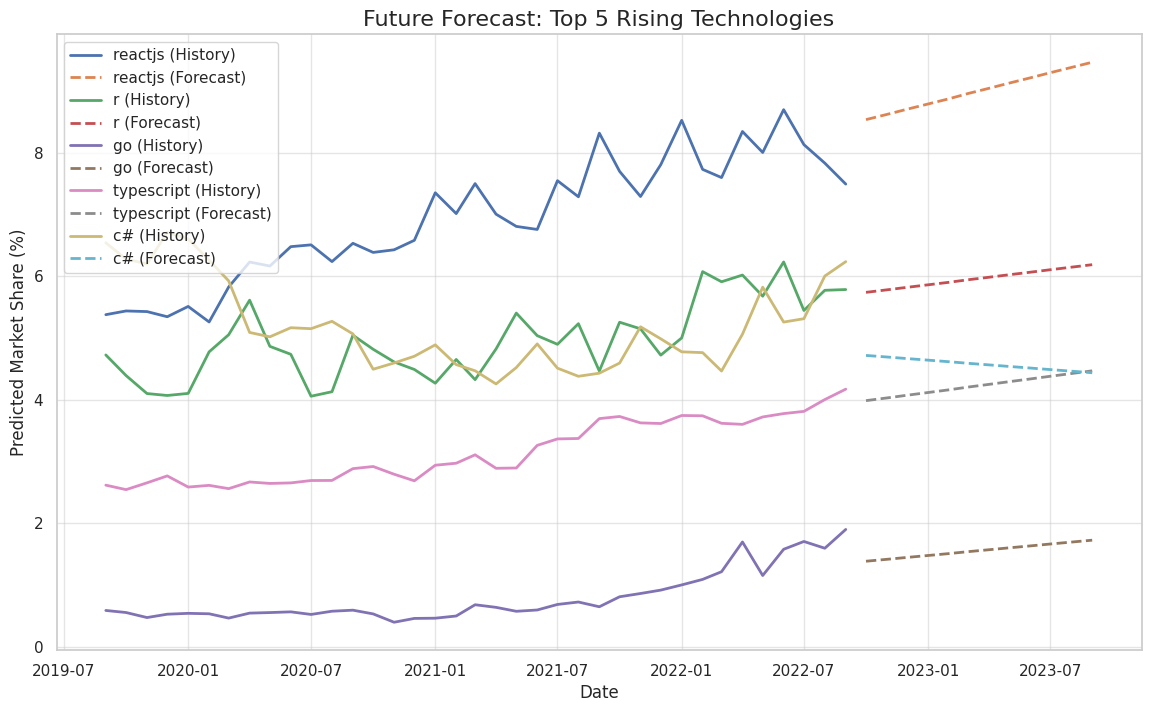

In [7]:
# Select Top 5 Growers to Forecast
forecast_tags = top_growers['tag'].head(5).tolist()

plt.figure(figsize=(14, 8))

for tag in forecast_tags:
    # Get historical data
    tag_data = trend_df[trend_df['tags'] == tag]
    
    # Fit model on recent history (last 3 years for stability)
    recent_history = tag_data[tag_data['month_dt'] >= (last_date - pd.DateOffset(months=36))]
    
    X = np.arange(len(recent_history)).reshape(-1, 1)
    y = recent_history['percentage'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Forecast next 12 months
    future_X = np.arange(len(recent_history), len(recent_history) + 12).reshape(-1, 1)
    future_y = model.predict(future_X)
    
    # Create dates for plot
    hist_dates = recent_history['month_dt']
    future_dates = [last_date + pd.DateOffset(months=i+1) for i in range(12)]
    
    # Plot History
    plt.plot(hist_dates, y, label=f"{tag} (History)", linewidth=2)
    
    # Plot Forecast
    plt.plot(future_dates, future_y, linestyle='--', linewidth=2, label=f"{tag} (Forecast)")

plt.title('Future Forecast: Top 5 Rising Technologies', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Predicted Market Share (%)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()